# Example usage

To use `pyecsago` in a project:

In [1]:
import pyecsago

print(pyecsago.__version__)

0.1.0


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns

from matplotlib.patches import Circle
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score, pairwise_distances_argmin
from sklearn.preprocessing import MinMaxScaler

from pyecsago.implementations.ecsago.algorithm import ECSAGO

In [3]:
def generate_synthetic_data(n_samples=300, n_centers=6, n_features=3, std=0.5, random_state=42):
    """Generate synthetic data with well-defined clusters.
    
    Creates a 2D dataset with visible clusters to visually evaluate
    the algorithm's performance.
    """
    X, y, centers = make_blobs(
        n_samples=n_samples,
        centers=n_centers,
        n_features=n_features,
        cluster_std=std,
        random_state=random_state,
        return_centers=True
    )
    
    # Normalize data to range (0, 1)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    centers_scaled = scaler.transform(centers)
    
    return X_scaled, y, centers_scaled

In [4]:
def generate_noisy_overlapping_data(n_samples=300, n_centers=4, n_features=3, std=1.5, noise=0.05, random_state=42):
    from sklearn.datasets import make_blobs
    from sklearn.preprocessing import MinMaxScaler

    # Generate base data with more overlap (higher std)
    X, y, centers = make_blobs(
        n_samples=n_samples,
        centers=n_centers,
        n_features=n_features,
        cluster_std=std,
        random_state=random_state,
        return_centers=True
    )

    # Add Gaussian noise to points
    rng = np.random.RandomState(random_state)
    noise_matrix = noise * rng.randn(*X.shape)
    X_noisy = X + noise_matrix

    # Normalize
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_noisy)
    centers_scaled = scaler.transform(centers)

    return X_scaled, y, centers_scaled

In [5]:
def visualize_results_with_radii(data, prototypes, cluster_assignments=None, figsize=(12, 8)):
    """Visualize data, prototypes, and cluster radii found by ECSAGO.
    
    Args:
        data: Numpy array with the original data (n_samples, n_features).
        prototypes: List of prototypes found by ECSAGO.
        cluster_assignments: Array with cluster assignments for each point.
        figsize: Tuple with the figure size (width, height).
    """
    from matplotlib.colors import ListedColormap
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    sns.set_theme(style="darkgrid")
    
    n_clusters = len(prototypes)
    palette = sns.color_palette('husl', n_clusters)
    cmap = ListedColormap(palette)
    
    # Plot original data
    if cluster_assignments is not None:
        ax.scatter(data[:, 0], data[:, 1], 
                   c=cluster_assignments, 
                   alpha=0.4, 
                   cmap=cmap,
                   s=8)
    else:
        ax.scatter(data[:, 0], data[:, 1], 
                   alpha=0.4,
                   c='gray',
                   s=8)
    
    # Compute prototype coordinates and radii
    prototypes_coords = np.array([p.genome for p in prototypes])
    radii = np.array([p.get_radius(k=13.8) for p in prototypes])
    
    # Draw circles for cluster radii
    for i, (prototype, radius) in enumerate(zip(prototypes_coords, radii)):
        circle = Circle(
            prototype, 
            radius,
            fill=False,
            linestyle='--',
            color=palette[i],
            linewidth=1.5,
            alpha=0.8
        )
        ax.add_patch(circle)
    
    # Plot centroids (prototypes)
    ax.scatter(
        prototypes_coords[:, 0],
        prototypes_coords[:, 1],
        c='red',
        marker='*',
        s=200,
        edgecolors='black',
        linewidths=0.5,
        zorder=5,
        label='Prototypes'
    )
    
    # Add labels for each prototype
    for i, (x, y) in enumerate(prototypes_coords):
        ax.annotate(
            f'E{i + 1}\nr={radii[i]:.3f}',
            (x, y),
            fontsize=7,
            ha='center',
            va='bottom',
            xytext=(0, 8),
            textcoords='offset points',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )
    
    ax.legend(fontsize=10)
    ax.set_title('ECSAGO Clustering Results', fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig('ecsago.png', dpi=200, bbox_inches='tight')
    plt.show()

100%|██████████| 30/30 [00:01<00:00, 18.97it/s]


Prototypes found: 4


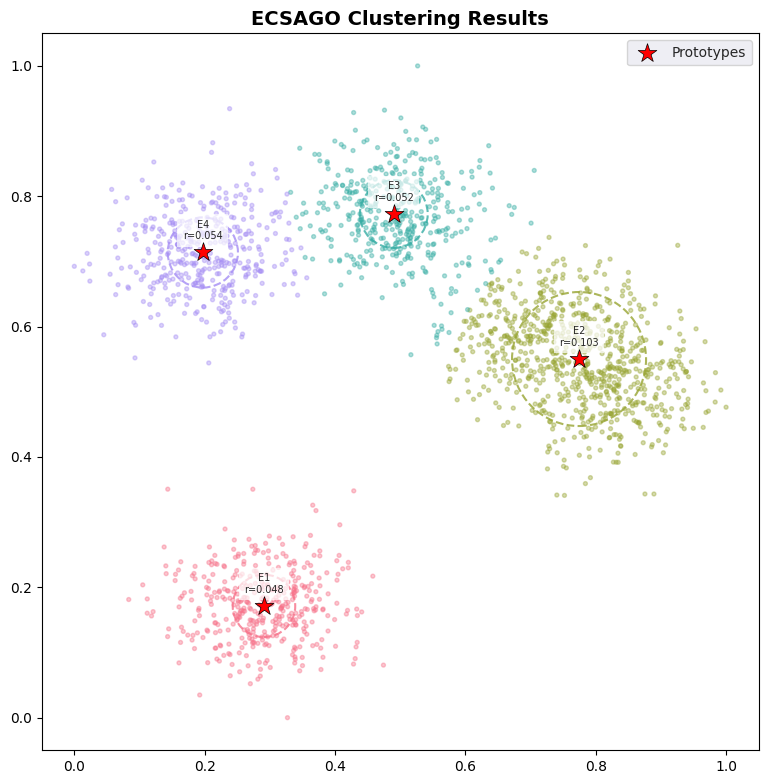


True centers vs. ECSAGO centers:
  True 0: [0.49284978 0.77784734]  ->  ECSAGO: [0.49021492 0.77277103]  | dist: 0.0057
  True 1: [0.82358313 0.50817194]  ->  ECSAGO: [0.77442287 0.55029463]  | dist: 0.0647
  True 2: [0.29066326 0.16909055]  ->  ECSAGO: [0.29100288 0.17153261]  | dist: 0.0025
  True 3: [0.2000491  0.71309095]  ->  ECSAGO: [0.19717431 0.71374943]  | dist: 0.0029
  True 4: [0.70248769 0.59198334]  ->  ECSAGO: [0.77442287 0.55029463]  | dist: 0.0831

Adjusted Rand Index: 0.7512


In [6]:
# Generate synthetic data (or use uploaded: X = _uploaded_data)
X, true_labels, true_centers = generate_noisy_overlapping_data(
    n_samples=2000, n_centers=5, n_features=2, std=1.5, noise=0.05, random_state=42
)

# Configure ECSAGO
config = {
    'population_size': 100,
    'weight_threshold': 0.3,
    'max_generations': 30,
    'iterations': 10,
    'pct_max_fitness': 0.25,
    'extraction_type': {2: 0.25},
    'k': 13.8,
    'use_cuda': False,
}

# Run the algorithm
ecsago = ECSAGO(config)
results = ecsago.run(X)

refined_prototypes = results['refined_prototypes']
assignments = results['cluster_assignments']

print(f"Prototypes found: {len(refined_prototypes)}")

# Visualize
visualize_results_with_radii(X, refined_prototypes, cluster_assignments=assignments)

# Evaluate against ground truth
ecsago_centers = np.array([p.genome for p in refined_prototypes])
closest = pairwise_distances_argmin(true_centers, ecsago_centers)

print("\nTrue centers vs. ECSAGO centers:")
for i, idx in enumerate(closest):
    dist = np.linalg.norm(true_centers[i] - ecsago_centers[idx])
    print(f"  True {i}: {true_centers[i]}  ->  ECSAGO: {ecsago_centers[idx]}  | dist: {dist:.4f}")

ari = adjusted_rand_score(true_labels, assignments)
print(f"\nAdjusted Rand Index: {ari:.4f}")

# ECSAGO vs K-means

Comparison of cluster centers found by ECSAGO and K-means on various datasets.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

def load_dataset_from_file(file_path):
    """Load a numeric dataset from a text file (CSV, TSV, or space-delimited).
    
    Args:
        file_path: Path to the file. First row is skipped (header).
    
    Returns:
        np.ndarray with the loaded data, or None on error.
    """
    if not os.path.isfile(file_path):
        print(f"File not found: '{file_path}'")
        return None
    try:
        return np.loadtxt(file_path, skiprows=1)
    except Exception as e:
        print(f"Error reading '{file_path}': {e}")
        return None

file_upload = widgets.FileUpload(accept='.txt,.csv,.tsv', multiple=False, description='Load dataset')
output = widgets.Output()

def on_upload(change):
    with output:
        output.clear_output()
        uploaded = file_upload.value
        if uploaded:
            item = uploaded[0]
            content = item['content'].tobytes().decode('utf-8')
            lines = content.strip().split('\n')
            # Skip header, parse numeric data
            data_lines = lines[1:] if len(lines) > 1 else lines
            import io
            file_data = np.loadtxt(io.StringIO('\n'.join(data_lines)))
            # Store in global scope for use in subsequent cells
            import builtins
            builtins._uploaded_data = file_data
            print(f"Loaded dataset: {file_data.shape[0]} samples, {file_data.shape[1]} features")
            print(f"Access it via: X = _uploaded_data")

file_upload.observe(on_upload, names='value')
display(widgets.VBox([widgets.Label('Upload a dataset file (optional):'), file_upload, output]))

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

# 1. Load dataset
data = _uploaded_data
print(f"Dataset: {data.shape[0]} points, {data.shape[1]} dimensions")

# 2. Run ECSAGO
np.random.seed(42)
config = {
    'population_size': 30,
    'weight_threshold': 0.3,
    'max_generations': 30,
    'iterations': 10,
    'extraction_type': {2: 0.25},
    'k': 13.8,
    'use_cuda': False,
}

ecsago = ECSAGO(config)
results = ecsago.run(data)

ecsago_prototypes = results['refined_prototypes']
ecsago_centers = np.array([p.genome for p in ecsago_prototypes])
ecsago_radii = np.array([float(p.get_radius(k=13.8)) for p in ecsago_prototypes])
ecsago_assignments = results['cluster_assignments']
n_clusters_ecsago = len(ecsago_prototypes)

print(f"ECSAGO found {n_clusters_ecsago} clusters")

# 3. Run K-means with the same number of clusters detected by ECSAGO
kmeans = KMeans(n_clusters=n_clusters_ecsago, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(data)
kmeans_centers = kmeans.cluster_centers_

# 4. Match centers: for each K-means center, find the closest ECSAGO center
closest_idx, closest_dist = pairwise_distances_argmin_min(kmeans_centers, ecsago_centers)

print(f"\n{'='*70}")
print(f"{'K-means Center':>30s}  {'ECSAGO Center':>30s}  {'Dist':>8s}")
print(f"{'='*70}")
for i in range(n_clusters_ecsago):
    j = closest_idx[i]
    km_c = kmeans_centers[i]
    ec_c = ecsago_centers[j]
    print(f"  ({km_c[0]:.4f}, {km_c[1]:.4f})       ({ec_c[0]:.4f}, {ec_c[1]:.4f})      {closest_dist[i]:.4f}")

print(f"\nMean distance between centers: {np.mean(closest_dist):.4f}")
print(f"Max distance:                  {np.max(closest_dist):.4f}")

Dataset: 10000 points, 2 dimensions


100%|██████████| 30/30 [00:00<00:00, 32.20it/s]


ECSAGO found 13 clusters

                K-means Center                   ECSAGO Center      Dist
  (0.3889, 0.2267)       (0.3901, 0.1521)      0.0747
  (0.6813, 0.7234)       (0.8379, 0.7432)      0.1578
  (0.1502, 0.3176)       (0.1063, 0.3076)      0.0451
  (0.6820, 0.1814)       (0.7019, 0.2539)      0.0751
  (0.1745, 0.8239)       (0.2360, 0.8734)      0.0789
  (0.8465, 0.8826)       (0.8379, 0.7432)      0.1397
  (0.1570, 0.1415)       (0.1656, 0.1486)      0.0112
  (0.7962, 0.4307)       (0.7019, 0.2539)      0.2004
  (0.1836, 0.5997)       (0.2293, 0.7100)      0.1194
  (0.8753, 0.6305)       (0.8379, 0.7432)      0.1187
  (0.4706, 0.5680)       (0.5259, 0.5642)      0.0554
  (0.4591, 0.8355)       (0.4336, 0.8806)      0.0519
  (0.8947, 0.2389)       (0.9048, 0.2557)      0.0197

Mean distance between centers: 0.0883
Max distance:                  0.2004


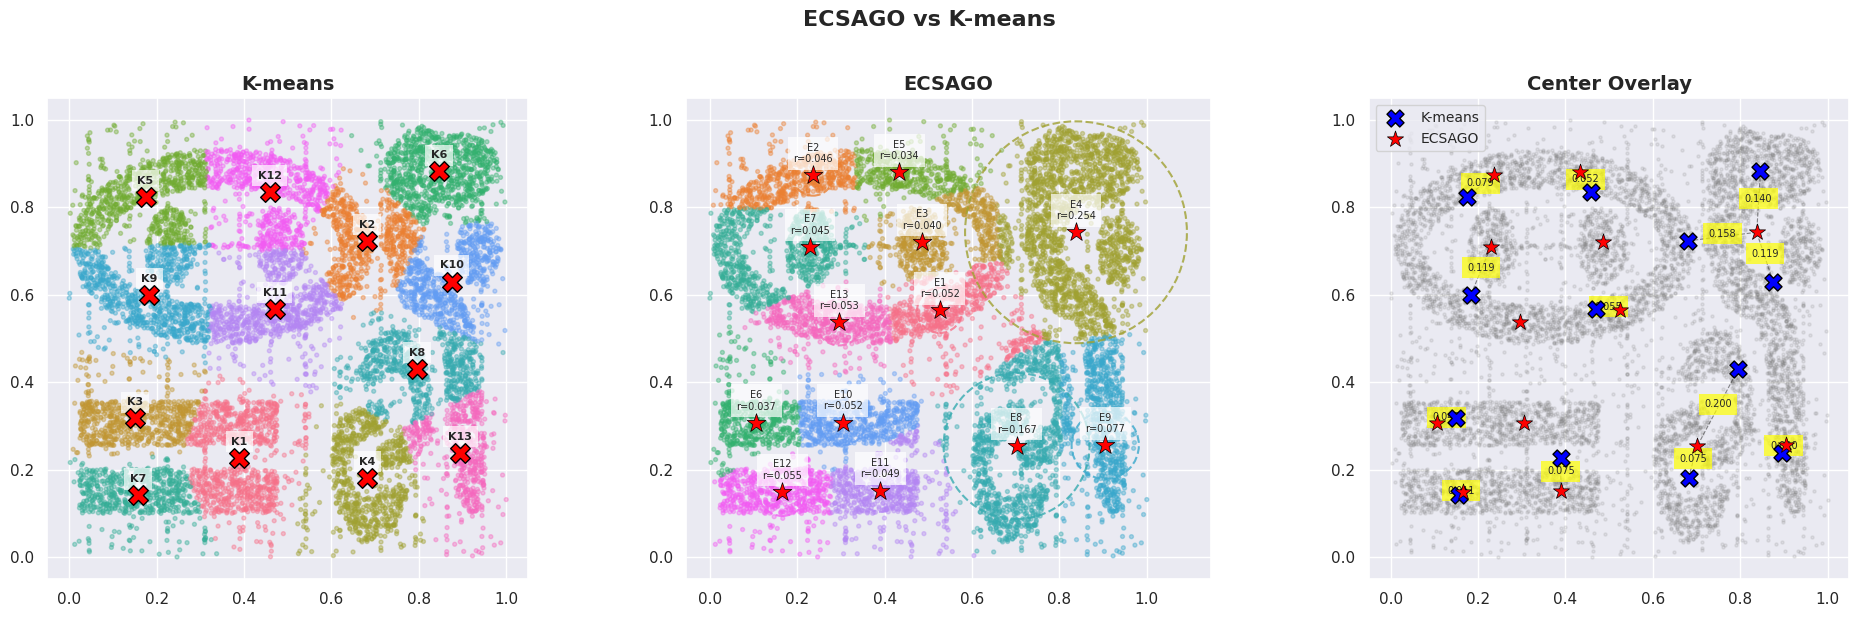

In [10]:
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="darkgrid")

palette = sns.color_palette('husl', n_clusters_ecsago)
cmap = ListedColormap(palette)

# --- Panel 1: K-means ---
ax = axes[0]
ax.scatter(data[:, 0], data[:, 1], c=kmeans_labels, alpha=0.4, cmap=cmap, s=8)
ax.scatter(kmeans_centers[:, 0], kmeans_centers[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidths=1, zorder=5)
for i, c in enumerate(kmeans_centers):
    ax.annotate(f'K{i+1}', c, fontsize=8, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.set_title('K-means', fontsize=14, fontweight='bold')
ax.set_aspect('equal')

# --- Panel 2: ECSAGO ---
ax = axes[1]
ax.scatter(data[:, 0], data[:, 1], c=ecsago_assignments, alpha=0.4, cmap=cmap, s=8)
ax.scatter(ecsago_centers[:, 0], ecsago_centers[:, 1], c='red', marker='*', s=200, edgecolors='black', linewidths=0.5, zorder=5)
for i, (c, r) in enumerate(zip(ecsago_centers, ecsago_radii)):
    circle = Circle(c, r, fill=False, linestyle='--', color=palette[i], linewidth=1.5, alpha=0.8)
    ax.add_patch(circle)
    ax.annotate(f'E{i+1}\nr={r:.3f}', c, fontsize=7, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.set_title('ECSAGO', fontsize=14, fontweight='bold')
ax.set_aspect('equal')

# --- Panel 3: Center overlay ---
ax = axes[2]
ax.scatter(data[:, 0], data[:, 1], alpha=0.15, c='gray', s=5)
ax.scatter(kmeans_centers[:, 0], kmeans_centers[:, 1], c='blue', marker='X', s=150, 
           edgecolors='black', linewidths=1, zorder=5, label='K-means')
ax.scatter(ecsago_centers[:, 0], ecsago_centers[:, 1], c='red', marker='*', s=150,
           edgecolors='black', linewidths=0.5, zorder=5, label='ECSAGO')
for i in range(n_clusters_ecsago):
    j = closest_idx[i]
    ax.plot([kmeans_centers[i, 0], ecsago_centers[j, 0]], 
            [kmeans_centers[i, 1], ecsago_centers[j, 1]], 
            'k--', alpha=0.5, linewidth=0.8)
    mid = (kmeans_centers[i] + ecsago_centers[j]) / 2
    ax.annotate(f'{closest_dist[i]:.3f}', mid, fontsize=7, ha='center',
                bbox=dict(facecolor='yellow', alpha=0.7, edgecolor='none'))
ax.legend(fontsize=10)
ax.set_title('Center Overlay', fontsize=14, fontweight='bold')
ax.set_aspect('equal')

plt.suptitle('ECSAGO vs K-means', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ecsago_vs_kmeans.png', dpi=200, bbox_inches='tight')
plt.show()